# SWAT Patrol Swarm — Evaluation Harness

Evaluates the patrol swarm's PII detection recall against the NVIDIA Nemotron-PII dataset.

**Run from the `patrolswarm/` directory:**
```bash
cd patrolswarm
jupyter notebook eval/run_eval.ipynb
```

| Mode | Description |
|------|-------------|
| `mock` | Regex-based simulation — no LLM calls, fast, good for testing the harness |
| `live` | Real patrol swarm — requires model endpoints configured in `.env` |

In [9]:
# ── Configuration — edit these before running ──────────────────────────────

N_POSITIVE   = 50        # number of PII-positive documents to evaluate
MODE         = "live"      # "live" (real LLM) | "mock" (regex simulation)
OUTPUT_DIR   = "eval_output"

# Path to the processed parquet, or "hf" to download directly from HuggingFace
DATASET_PATH = "eval_output/pii_agent_swarm/agent_swarm_docs.parquet"

# Set True to enable chain-of-thought logging (PATROL_THINKING=1)
# Only meaningful in live mode — thinking blocks are logged at INFO level.
THINKING     = False

LOG_LEVEL    = "INFO"      # DEBUG | INFO | WARNING | ERROR

In [10]:
import json
import logging
import os
import sys
from pathlib import Path

# Notebook lives in patrolswarm/eval/ — add patrolswarm/ to sys.path
# so 'from eval.xxx import ...' resolves correctly regardless of kernel CWD.
_patrolswarm_root = str(Path("..").resolve())
if _patrolswarm_root not in sys.path:
    sys.path.insert(0, _patrolswarm_root)

# Set PATROL_THINKING before any patrol_swarm import so config.py picks it up
if THINKING:
    os.environ["PATROL_THINKING"] = "1"

# Configure logging so [THINKING] / [VOTE] / [WARNING] blocks appear in output
logging.basicConfig(
    level=getattr(logging, LOG_LEVEL),
    format="%(asctime)s %(levelname)-8s %(name)s — %(message)s",
    datefmt="%Y-%m-%dT%H:%M:%S",
    stream=sys.stderr,
    force=True,  # override any previous basicConfig call
)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"Mode:        {MODE.upper()}")
print(f"N_POSITIVE:  {N_POSITIVE}")
print(f"Dataset:     {DATASET_PATH}")
print(f"Thinking:    {'ON' if THINKING else 'OFF'}")
print(f"Root:        {_patrolswarm_root}")

Mode:        LIVE
N_POSITIVE:  50
Dataset:     eval_output/pii_agent_swarm/agent_swarm_docs.parquet
Thinking:    OFF
Root:        /Users/lucas/Documents/sonex_hackfest/patrolswarm


In [11]:
from eval.dataset import load_nemotron_pii, load_processed_pii

if DATASET_PATH.lower() == "hf":
    positive_docs, negative_docs, all_labels = load_nemotron_pii(N_POSITIVE, 0)
else:
    positive_docs, negative_docs, all_labels = load_processed_pii(DATASET_PATH, N_POSITIVE)

print(f"\nPositive docs loaded: {len(positive_docs)}")
print(f"Negative docs loaded: {len(negative_docs)}")
print(f"Unique PII labels in set: {len(all_labels)}")

Loading processed PII dataset from eval_output/pii_agent_swarm/agent_swarm_docs.parquet ...
  Loaded 49,140 rows
  Found 55 unique PII labels
  Eval set: 50 documents (all positive — all contain PII)
  Negative set: 0 (dataset contains only PII documents)

Positive docs loaded: 50
Negative docs loaded: 0
Unique PII labels in set: 55


In [12]:
import asyncio
from eval.harness import run_evaluation

# Jupyter's event loop is already running, so asyncio.run() raises RuntimeError.
# nest_asyncio patches it to allow nested calls — no other change needed.
try:
    import nest_asyncio
    nest_asyncio.apply()
except ImportError:
    pass  # not installed — top-level await may still work in IPython ≥ 7.0

results = asyncio.run(run_evaluation(positive_docs, negative_docs, mode=MODE))

2026-02-27T04:21:05 INFO     patrol_swarm.graph — ═══ Sweep cycle 1 starting ═══



Evaluating 50 positive documents (should flag)...

  [+1] domain='Marketing' → patrol='document'
         labels=['url', 'user_name', 'occupation', 'user_name', 'email']
         text preview: 'To begin our SEO strategy, we need to establish clear goals and target audience analysis. Our primary objective is to in'


2026-02-27T04:21:26 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T04:21:26 INFO     patrol_swarm.orchestrator — Cycle 1 assignments: {'eval_agent_199bc1ec': ['doc_patrol']}
2026-02-27T04:21:45 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T04:21:45 INFO     patrol_swarm.agents.base_patrol — doc_patrol → VOTE Severity.HIGH on eval_agent_199bc1ec (conf=0.95)
2026-02-27T04:22:41 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T04:22:41 WARNING  patrol_swarm.orchestrator — PatrolFlag produced: agent=eval_agent_199bc1ec severity=HIGH confidence=0.95
2026-02-27T04:22:41 INFO     patrol_swarm.graph — Cycle 1 complete | signals=1 votes=1 flags=1 duration=56085ms
2026-02-27T04:22:41 INFO     patrol_swarm.graph — ═══ Sweep cycle 1 starting ═══


         → FLAGGED  severity=HIGH confidence=0.95 detected=['email_address']

  [+2] domain='Consulting' → patrol='document'
         labels=['occupation', 'date', 'company_name', 'company_name', 'company_name', 'street_address', 'city', 'state', 'postcode', 'credit_debit_card', 'email', 'phone_number', 'date_time', 'url']
         text preview: 'This Consulting and Vendor Agreement is entered into on 2024-02-16 between VistaPoint Consulting and the client. VistaPo'


2026-02-27T04:23:04 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T04:23:04 INFO     patrol_swarm.orchestrator — Cycle 1 assignments: {'eval_agent_7e80b123': ['doc_patrol']}
2026-02-27T04:23:23 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T04:23:23 INFO     patrol_swarm.agents.base_patrol — doc_patrol → VOTE Severity.HIGH on eval_agent_7e80b123 (conf=0.95)
2026-02-27T04:24:16 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T04:24:16 WARNING  patrol_swarm.orchestrator — PatrolFlag produced: agent=eval_agent_7e80b123 severity=HIGH confidence=0.95
2026-02-27T04:24:16 INFO     patrol_swarm.graph — Cycle 1 complete | signals=1 votes=1 flags=1 duration=52915ms
2026-02-27T04:24:16 INFO     patrol_swarm.graph — ═══ Sweep cycle 1 starting ═══


...

         → FLAGGED  severity=HIGH confidence=0.98 detected=['person_name', 'date_of_birth', 'email_address', 'phone_number', 'street_address', 'medical_record_number', 'biometric_identifier']

  [+49] domain='Consulting' → patrol='document'
         labels=['company_name', 'company_name', 'date', 'employment_status', 'user_name', 'race_ethnicity', 'user_name', 'email', 'employment_status', 'company_name', 'fax_number']
         text preview: '### ConsultPro User Experience Report  #### Executive Summary The User Experience (UX) Report for ConsultPro, generated '


2026-02-27T06:04:05 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T06:04:05 INFO     patrol_swarm.orchestrator — Cycle 1 assignments: {'eval_agent_4a71bd20': ['doc_patrol']}
2026-02-27T06:04:27 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T06:04:27 INFO     patrol_swarm.agents.base_patrol — doc_patrol → VOTE Severity.HIGH on eval_agent_4a71bd20 (conf=0.95)
2026-02-27T06:05:33 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T06:05:33 WARNING  patrol_swarm.orchestrator — PatrolFlag produced: agent=eval_agent_4a71bd20 severity=HIGH confidence=0.95
2026-02-27T06:05:33 INFO     patrol_swarm.graph — Cycle 1 complete | signals=1 votes=1 flags=1 duration=66271ms
2026-02-27T06:05:33 INFO     patrol_swarm.graph — ═══ Sweep cycle 1 starting ═══


         → FLAGGED  severity=HIGH confidence=0.95 detected=['email_address', 'phone_number']

  [+50] domain='Advertising' → patrol='document'
         labels=['date', 'url', 'occupation', 'date', 'url', 'occupation', 'date', 'url', 'occupation', 'date', 'company_name', 'email', 'occupation', 'date', 'time', 'url', 'occupation', 'date', 'url', 'occupation', 'date', 'date_time', 'occupation']
         text preview: '| Post Date | Platform | Content Type | Caption or Copy | Target Audience | Hashtags | Performance Metrics | Notes | |--'


2026-02-27T06:05:57 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T06:05:57 INFO     patrol_swarm.orchestrator — Cycle 1 assignments: {'eval_agent_556b9597': ['doc_patrol']}
2026-02-27T06:06:22 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T06:06:22 INFO     patrol_swarm.agents.base_patrol — doc_patrol → VOTE Severity.HIGH on eval_agent_556b9597 (conf=0.95)
2026-02-27T06:07:26 INFO     httpx — HTTP Request: POST http://localhost:1234/v1/chat/completions "HTTP/1.1 200 OK"
2026-02-27T06:07:26 WARNING  patrol_swarm.orchestrator — PatrolFlag produced: agent=eval_agent_556b9597 severity=HIGH confidence=0.95
2026-02-27T06:07:26 INFO     patrol_swarm.graph — Cycle 1 complete | signals=1 votes=1 flags=1 duration=63477ms


         → FLAGGED  severity=HIGH confidence=0.95 detected=['email_address']
  [50/50] 6380.5s elapsed

Evaluating 0 negative documents (should NOT flag)...


In [13]:
from eval.metrics import compute_metrics

metrics = compute_metrics(results)


PATROL SWARM EVALUATION RESULTS
  Documents evaluated:  50
  True Positives (caught):   50
  False Negatives (missed):  0
  (No negative documents — recall-only evaluation)
  ────────────────────────────────────────────────────────
  Recall:               100.00%  ← primary metric
  ────────────────────────────────────────────────────────
  Per-label recall:
    credit_debit_card              100.0% ████████████████████ (8/8)
    biometric_identifier           100.0% ████████████████████ (8/8)
    national_id                    100.0% ████████████████████ (2/2)
    ssn                            100.0% ████████████████████ (6/6)
    medical_record_number          85.7% █████████████████ (6/7)
    street_address                 80.0% ████████████████ (8/10)
    bank_routing_number            80.0% ████████████████ (4/5)
    date_of_birth                  71.4% ██████████████ (5/7)
    employee_id                    66.7% █████████████ (2/3)
    pin                            66.7% ████

In [14]:
# Save raw results to disk
results_path = Path(OUTPUT_DIR) / "eval_results.json"
with open(results_path, "w") as f:
    json.dump({"results": results, "metrics": metrics}, f, indent=2, default=str)
print(f"Saved: {results_path}")

# Key numbers summary
cm = metrics["confusion_matrix"]
print(f"""
Confusion matrix:
  TP (caught)  : {cm['tp']}
  FN (missed)  : {cm['fn']}
  FP           : {cm['fp']}
  TN           : {cm['tn']}

Recall     : {metrics['recall']:.1%}  ← primary metric
Precision  : {metrics['precision']:.1%}
F1 Score   : {metrics['f1']:.1%}
Accuracy   : {metrics['accuracy']:.1%}
""")

Saved: eval_output/eval_results.json

Confusion matrix:
  TP (caught)  : 50
  FN (missed)  : 0
  FP           : 0
  TN           : 0

Recall     : 100.0%  ← primary metric
Precision  : 100.0%
F1 Score   : 100.0%
Accuracy   : 100.0%



  Saved eval_output/eval_summary.png
  Saved eval_output/eval_confidence_dist.png
  Saved eval_output/eval_latency.png
Chart: eval_output/eval_summary.png


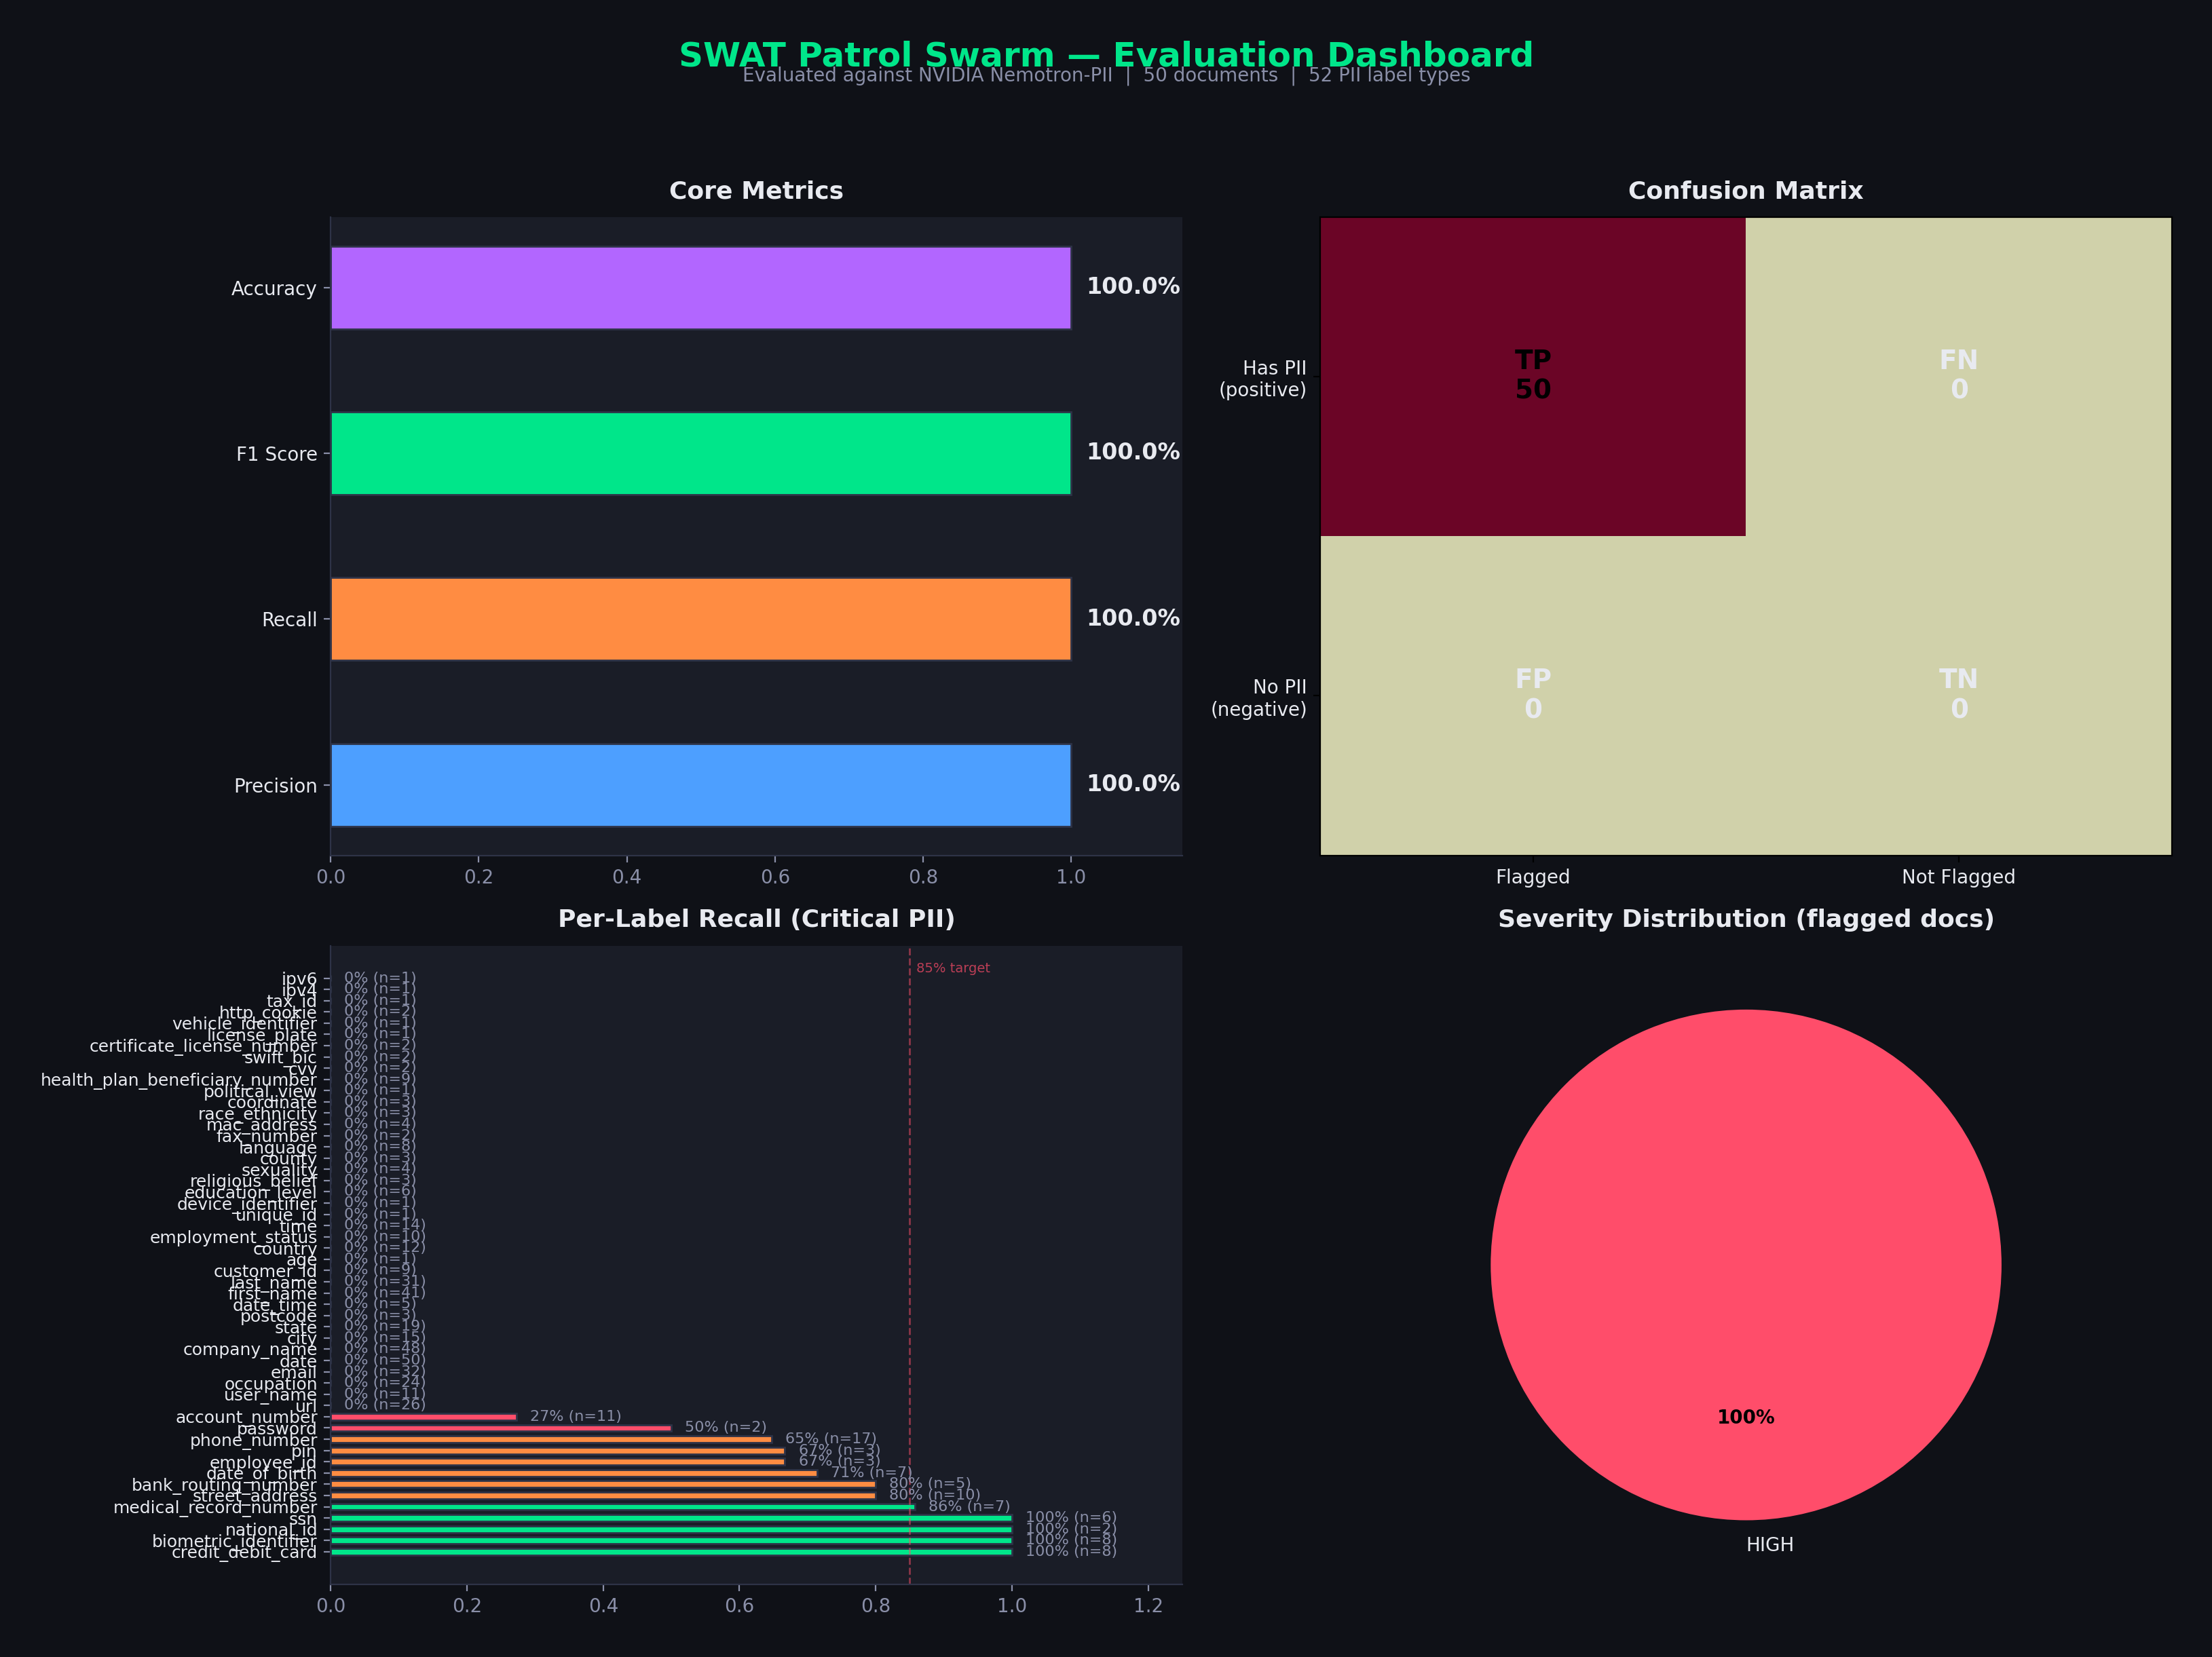

Chart: eval_output/eval_confidence_dist.png


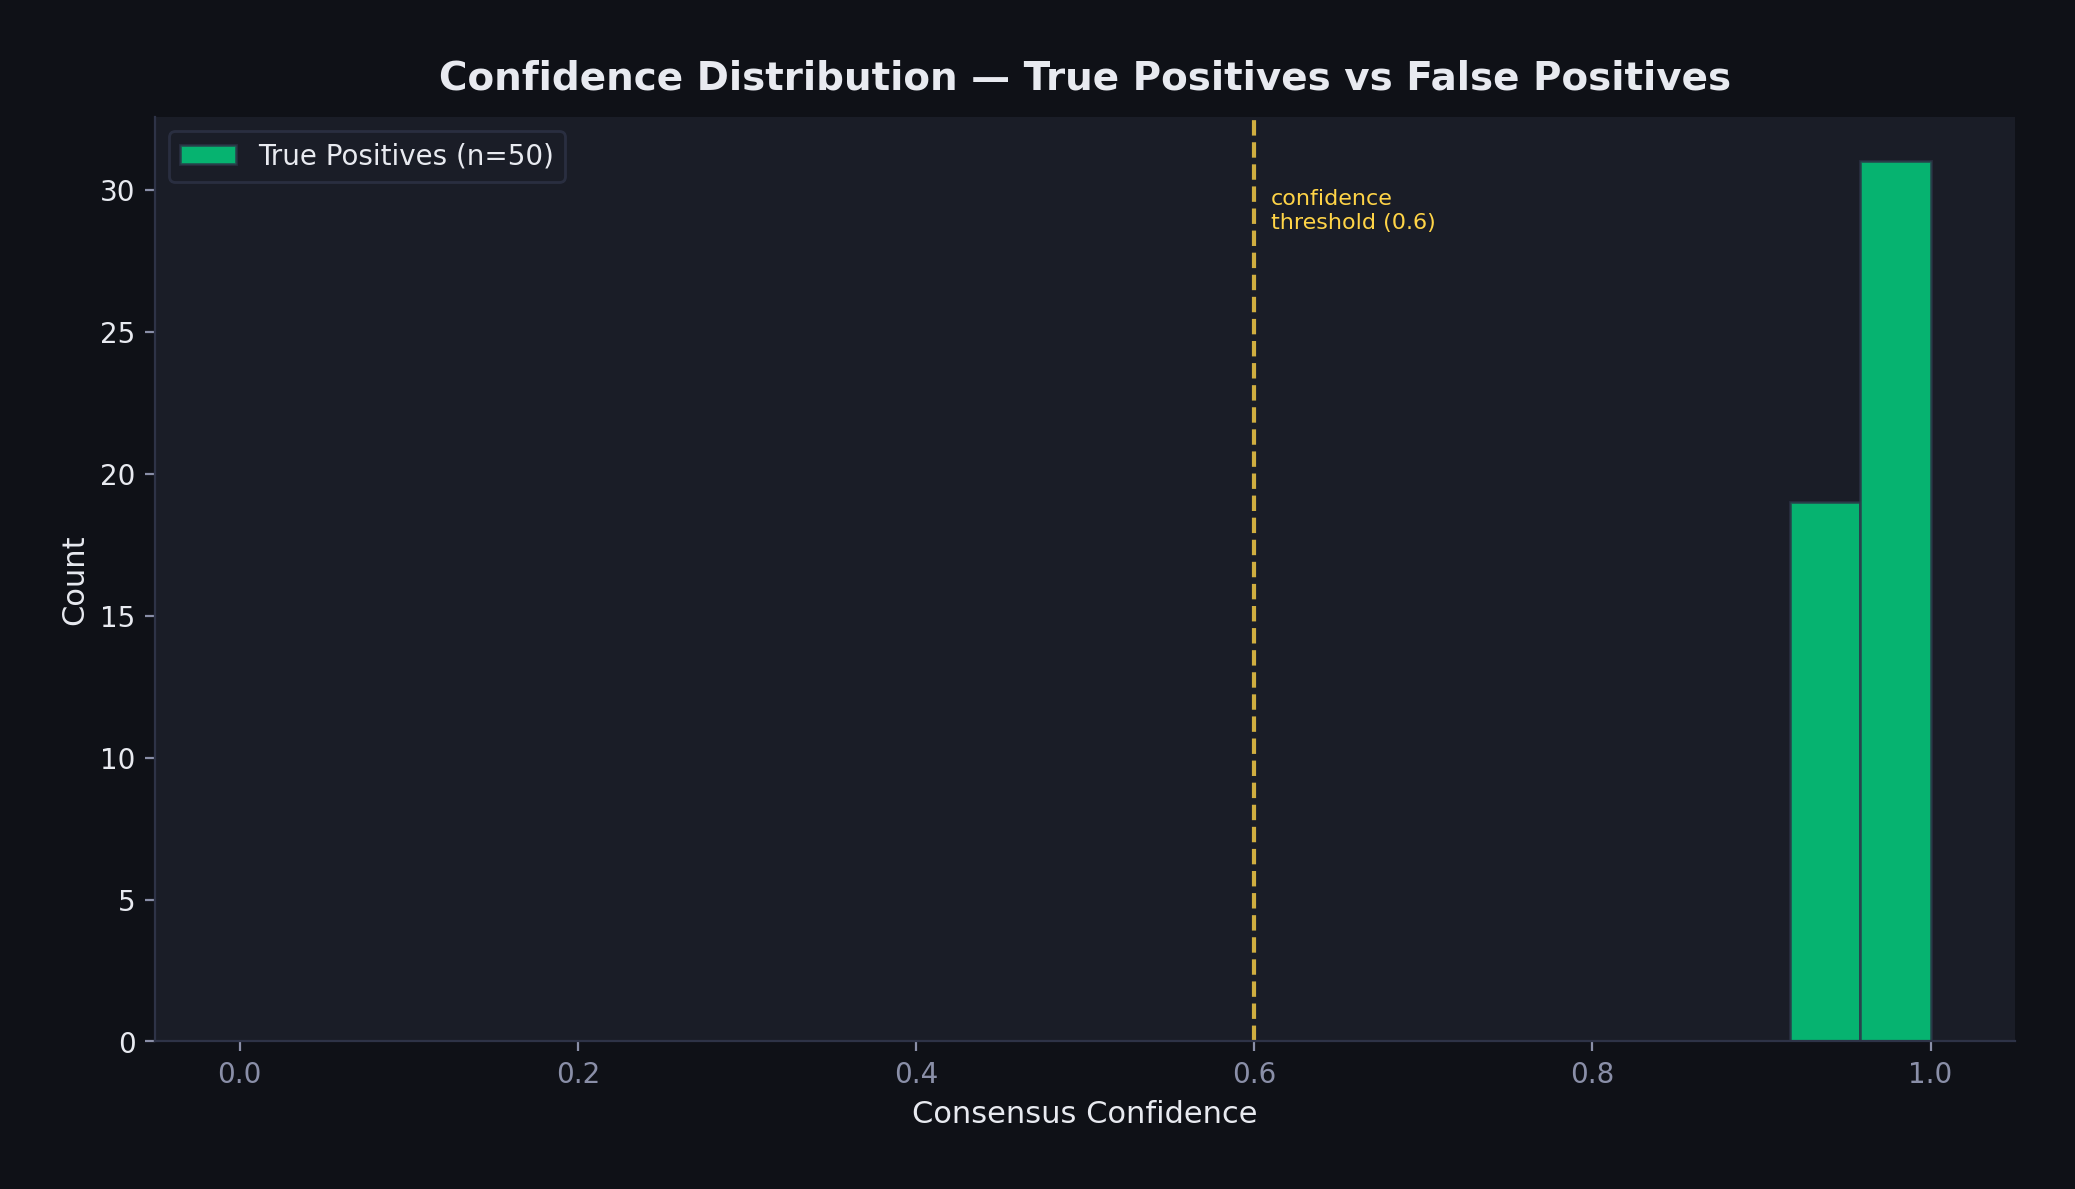

Chart: eval_output/eval_latency.png


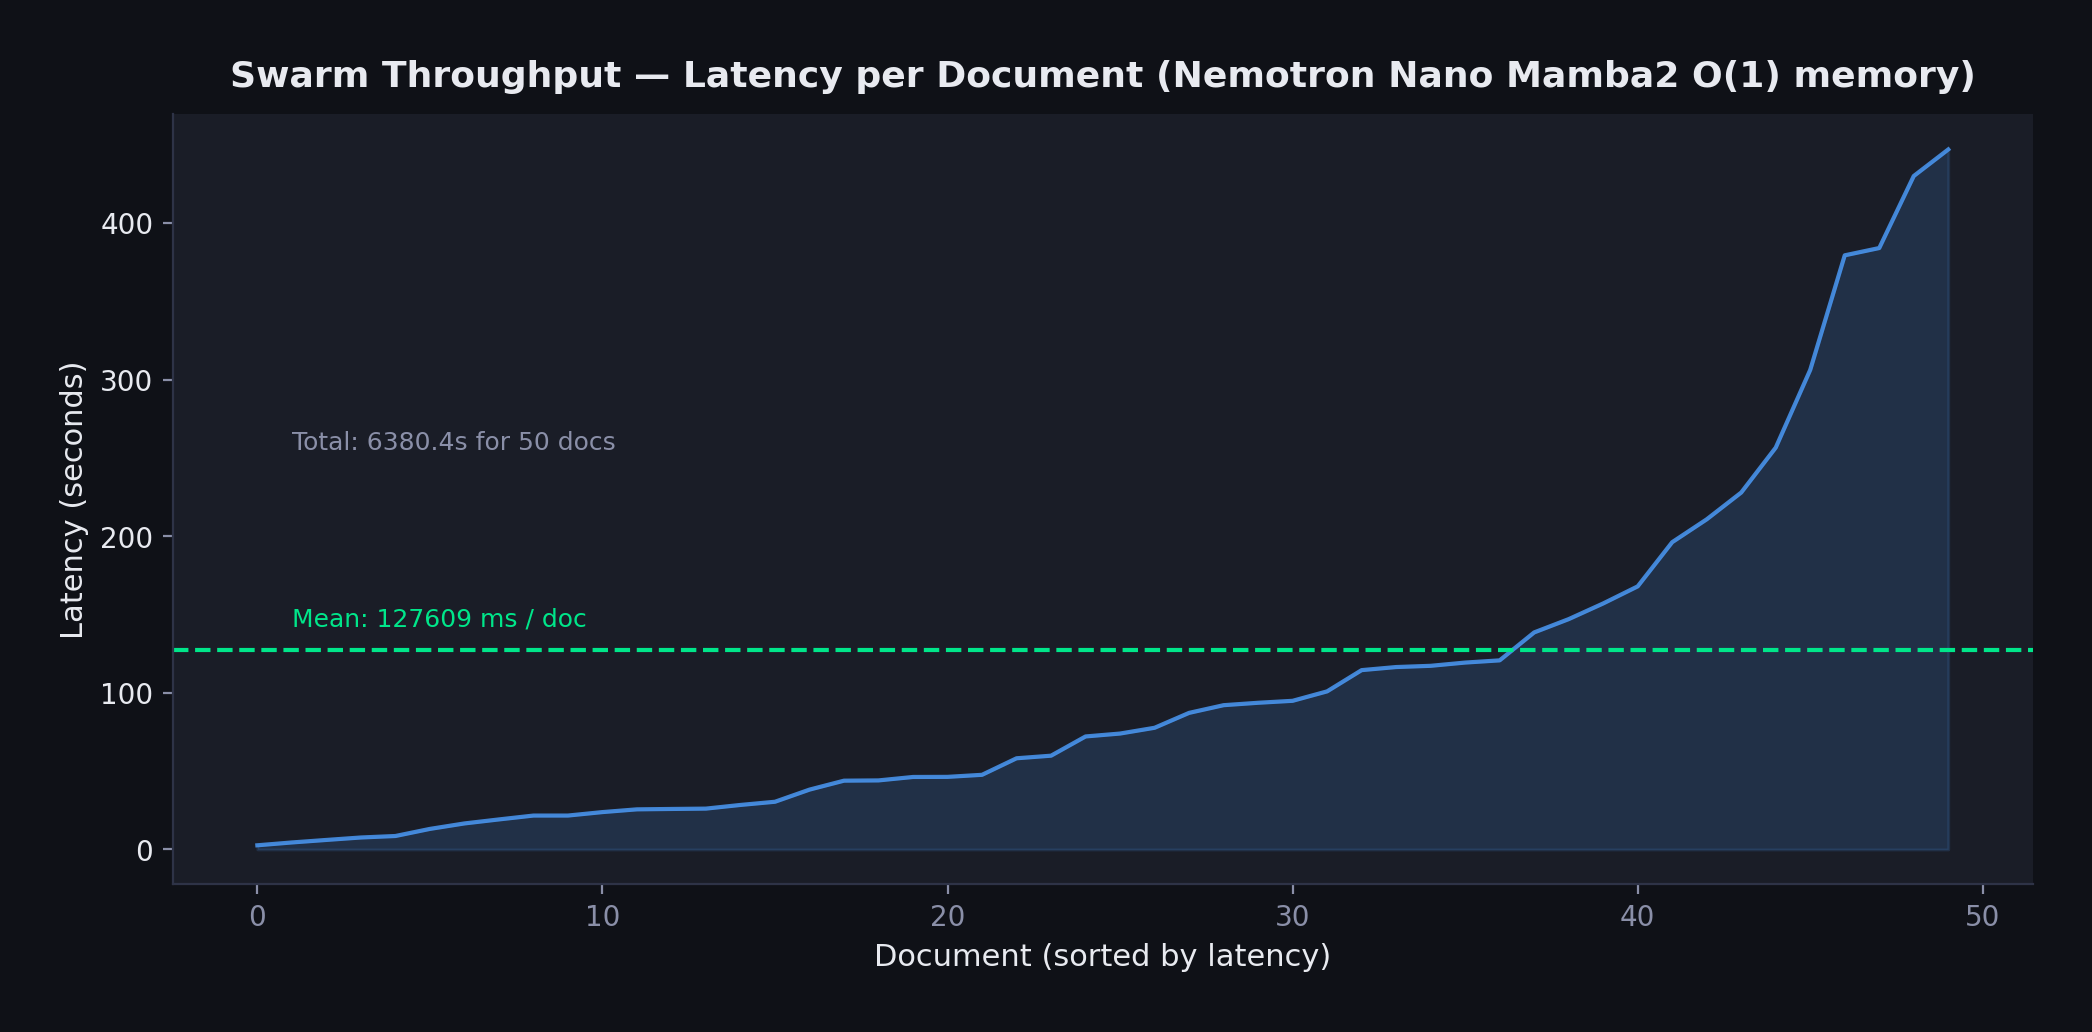

In [15]:
from eval.charts import generate_eval_charts
from IPython.display import Image, display

chart_paths = generate_eval_charts(results, metrics, output_dir=OUTPUT_DIR)

for p in chart_paths:
    print(f"Chart: {p}")
    display(Image(filename=str(p)))